<div align="center">

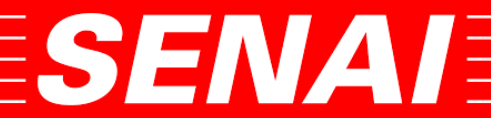

</div>

<div align="center" style="font-size: 40px;">

**Ciência de Dados**

</div>

# 🏆 Desafio: Tipos de Dados com Python

### 🎯 Objetivo:
Realizar a integração e o tratamento de dados hospitalares sem o uso de bibliotecas de alto nível (como Pandas) para cálculos ou Regex para textos. 

O foco é o domínio de **Lógica de Programação**, **Dicionários** e **Tipos de Dados**.

### ⚠️ Regras da Atividade:
1. **Proibido** usar `.mean()`, `.sum()` ou `.groupby()` do Pandas.

2. **Proibido** usar a biblioteca `re` (Regex).

## 🏗️ Setup dos Dados
Execute esta célula para criar os arquivos brutos que você deverá processar.

In [1]:
import pandas as pd
import json

# Criando CSV Mascarado (uid=ID, v1=Idade, v2=Escolaridade)
csv_data = {
    'uid': [101, 102, 103, 104, 105],
    'v1': [45, -5, '62', 50, 250], 
    'v2': ['Superior', 'médio', 'Pós-Graduação', 'superior', 'médio'],
    'local': ['São Paulo', 'Curitiba', 'São Paulo', 'Belo Horizonte', 'Curitiba']
}
pd.DataFrame(csv_data).to_csv('dados_hospitalares.csv', index=False)

# Criando JSON com escalas variadas (Hz vs BPM)
json_data = [
    {'id': 101, 'unidade': 'BPM', 'leituras': [80, 85, 90]},
    {'id': 103, 'unidade': 'Hz',  'leituras': [1.5, 1.6, 1.7]}, 
    {'id': 105, 'unidade': 'BPM', 'leituras': []}
]
with open('sensores.json', 'w') as f:
    json.dump(json_data, f)

# Criando Notas Médicas (Não Estruturado)
with open('notas.txt', 'w') as f:
    f.write('ID:101 - Paciente com Hipertensão severa. ID:103 - Quadro estável. ID:105 - Apresenta Hipertensão.')

print('✅ Arquivos gerados com sucesso!')

✅ Arquivos gerados com sucesso!


### 🛠️ Item 1: Integração e Limpeza (30 pontos)
**Tarefa:** Carregue os dados do CSV para uma lista de dicionários. 
*   Trate a coluna `v1` (Idade): se for negativa ou maior que 120, mude para 0.

*   Normalize a coluna `v2` (Escolaridade) para minúsculo e sem espaços.

In [5]:
import pandas as pd

df = pd.read_csv('dados_hospitalares.csv')
dados = df.to_dict('records')

for pessoa in dados:

    idade = pessoa['v1']

    if type(idade) != int:
        idade = 0

    if idade < 0 or idade > 120:
        idade = 0

    pessoa['v1'] = idade

    pessoa['v2'] = str(pessoa['v2']).lower().strip()

    pessoa['local'] = str(pessoa['local']).lower().strip()
    
df = pd.DataFrame(dados)
print(df)

   uid  v1             v2           local
0  101  45       superior       são paulo
1  102   0          médio        curitiba
2  103  62  pós-graduação       são paulo
3  104  50       superior  belo horizonte
4  105   0          médio        curitiba


### 🚀 Item 2: Processamento e Conversão Técnica (40 pontos)
**Tarefa:** Relacione os dados dos pacientes com o arquivo `sensores.json`.
*   **Conversão:** Se a unidade for 'Hz', multiplique as leituras por 60 (para virar BPM).

*   **Texto:** Sem usar Regex, verifique se a palavra 'Hipertensão' aparece na nota do paciente no arquivo `notas.txt`.

*   **Cálculo:** Adicione as chaves `bpm_medio` e `tem_hipertensao` ao dicionário de cada paciente.

In [6]:
import json

with open('sensores.json', 'r') as f:
    sensores = json.load(f)

with open('notas.txt', 'r', encoding='latin-1') as f:
    notas = f.read()

for pessoa in dados:
    uid = pessoa['uid']

    sensor_encontrado = None
    for sensor in sensores:
        if sensor['id'] == uid:
            sensor_encontrado = sensor
            break

    bpm_medio = 0

    if sensor_encontrado and len(sensor_encontrado['leituras']) > 0:
        leituras = sensor_encontrado['leituras']

        if sensor_encontrado['unidade'] == 'Hz':
            leituras = [leitura * 60 for leitura in leituras]

        bpm_medio = sum(leituras) / len(leituras)

    pessoa['bpm_medio'] = round(bpm_medio, 2)

    tem_hipertensao = False
    for linha in notas.splitlines():
        if f'ID:{uid}' in linha:
            if 'Hipertensão' in linha:
                tem_hipertensao = True
            break

    pessoa['tem_hipertensao'] = tem_hipertensao

df = pd.DataFrame(dados)
print(df)

   uid  v1             v2           local  bpm_medio  tem_hipertensao
0  101  45       superior       são paulo       85.0             True
1  102   0          médio        curitiba        0.0            False
2  103  62  pós-graduação       são paulo       96.0             True
3  104  50       superior  belo horizonte        0.0            False
4  105   0          médio        curitiba        0.0             True


### 📊 Item 3: Relatório Estatístico (30 pontos)
**Tarefa:** Calcule a média de BPM de todos os pacientes hipertensos de São Paulo. 
*Não use funções prontas, faça a soma e divisão via loop.*

In [7]:
total_bpm = 0
quantidade = 0

for pessoa in dados:
    if pessoa['tem_hipertensao'] == True and pessoa['local'] == 'são paulo':
        total_bpm = total_bpm + pessoa['bpm_medio']
        quantidade = quantidade + 1

if quantidade > 0:
    media_bpm = total_bpm / quantidade
else:
    media_bpm = 0

print(f'Pacientes hipertensos de São Paulo: {quantidade}')
print(f'Média de BPM: {media_bpm:.2f}')

df = pd.DataFrame(dados)
print(df)

Pacientes hipertensos de São Paulo: 2
Média de BPM: 90.50
   uid  v1             v2           local  bpm_medio  tem_hipertensao
0  101  45       superior       são paulo       85.0             True
1  102   0          médio        curitiba        0.0            False
2  103  62  pós-graduação       são paulo       96.0             True
3  104  50       superior  belo horizonte        0.0            False
4  105   0          médio        curitiba        0.0             True
